#### GMM (Gaussian Mixture Models)


=== GMM (best n_components=1) — 16-state ===
Accuracy: 0.3870 (38.70%)

Confusion Matrix (rows=True, cols=Predicted):


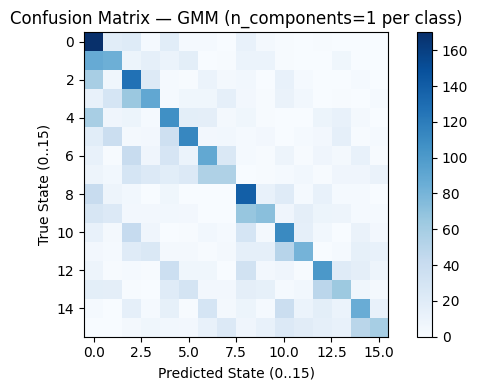

In [3]:
# GMM: یک مخلوط گاوسی per class
import os
os.environ["OMP_NUM_THREADS"] = "4"  # جلوگیری از هشدار KMeans روی Windows

import numpy as np
from sklearn.mixture import GaussianMixture
def load_dataset_gmm(X_path="dataset_X.txt", y_path="dataset_y.txt"):
    ...
def bits_to_int_labels(y_bits):
    ...
# بارگذاری و آماده‌سازی (همان فرمت QDA)
X_complex, y_bits = load_dataset_gmm()
X = np.hstack([X_complex.real, X_complex.imag])
y = bits_to_int_labels(y_bits)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
classes = np.unique(y)
n_components_list = [1,2, 3, 4, 5]
best_n = 2
best_acc_gmm = 0
results_gmm = {}
for n_comp in n_components_list:
    gmms = {}
    priors = {}
    for c in classes:
        Xc = X_train_s[y_train == c]
        priors[c] = len(Xc) / len(X_train_s)
        gmms[c] = GaussianMixture(
            n_components=n_comp,
            covariance_type="full",   #"tied",   #
            random_state=42,
            reg_covar=1e-5,
            n_init=3,
            init_params="random",
        ).fit(Xc)
    # پیش‌بینی: برای هر نمونه log P(x|s) + log P(s) از هر کلاس، سپس argmax
    log_probs = np.zeros((len(X_test_s), len(classes)))
    for i, c in enumerate(classes):
        log_probs[:, i] = gmms[c].score_samples(X_test_s) + np.log(priors[c])
    y_pred_gmm = classes[np.argmax(log_probs, axis=1)]
    acc = accuracy_score(y_test, y_pred_gmm)
    results_gmm[n_comp] = acc
    # print(f"GMM n_components={n_comp}  →  Accuracy = {acc:.4f} ({100*acc:.2f}%)")
    if acc > best_acc_gmm:
        best_acc_gmm = acc
        best_n = n_comp
        best_gmms = gmms
        best_priors = priors
# انتخاب n_components با BIC برای هر کلاس (۲ تا ۵)
n_candidates = [1,2, 3, 4, 5]
gmms_bic = {}
priors_bic = {}
n_per_class = {}
for c in classes:
    Xc = X_train_s[y_train == c]
    priors_bic[c] = len(Xc) / len(X_train_s)
    best_bic = np.inf
    best_gmm_c = None
    best_k_c = 2
    for k in n_candidates:
        if len(Xc) < k:
            continue
        g = GaussianMixture(
            n_components=k,
            covariance_type= "full",   #"tied", 
            random_state=42,
            reg_covar=1e-5,
            n_init=3,
            init_params="random",
        ).fit(Xc)
        bic = g.bic(Xc)
        if bic < best_bic:
            best_bic = bic
            best_gmm_c = g
            best_k_c = k
    gmms_bic[c] = best_gmm_c
    n_per_class[c] = best_k_c
log_probs_bic = np.zeros((len(X_test_s), len(classes)))
for i, c in enumerate(classes):
    log_probs_bic[:, i] = gmms_bic[c].score_samples(X_test_s) + np.log(priors_bic[c])
y_pred_bic = classes[np.argmax(log_probs_bic, axis=1)]
acc_bic = accuracy_score(y_test, y_pred_bic)
# print(f"\nGMM (BIC per-class, n in {n_candidates})  →  Accuracy = {acc_bic:.4f} ({100*acc_bic:.2f}%)")
# print("n_components per class:", n_per_class)
if acc_bic > best_acc_gmm:
    best_acc_gmm = acc_bic
    best_gmms = gmms_bic
    best_priors = priors_bic
    best_n = "BIC"
    y_pred_gmm_final = y_pred_bic
else:
    log_probs_final = np.zeros((len(X_test_s), len(classes)))
    for i, c in enumerate(classes):
        log_probs_final[:, i] = best_gmms[c].score_samples(X_test_s) + np.log(best_priors[c])
    y_pred_gmm_final = classes[np.argmax(log_probs_final, axis=1)]

# مدل نهایی با بهترین n_components (ثابت یا BIC)
cm_gmm = confusion_matrix(y_test, y_pred_gmm_final)
print(f"\n=== GMM (best n_components={best_n}) — 16-state ===")
print(f"Accuracy: {best_acc_gmm:.4f} ({100*best_acc_gmm:.2f}%)")
print("\nConfusion Matrix (rows=True, cols=Predicted):")
# print(cm_gmm)
plt.figure(figsize=(6, 4))
plt.imshow(cm_gmm, interpolation="nearest", cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted State (0..15)")
plt.ylabel("True State (0..15)")
plt.title(f"C Matrix — GMM (n_components={best_n} per class)")
plt.tight_layout()
plt.show()